Imports and Setup for the project

In [24]:
import os
import numpy as np

DATA_DIRECTORY = "data\out"
LAB_DIRECTORY = "data\cmu_us_slt_arctic\lab"
TRAIN_FILE = os.path.join(DATA_DIRECTORY, "train.txt")
VAL_FILE = os.path.join(DATA_DIRECTORY, "val.txt")
TEST_FILE = os.path.join(DATA_DIRECTORY, "test.txt")

def get_basenames(file_path):
    with open(file_path, 'r') as f:
        basenames = [line.strip() for line in f.readlines()]
    return basenames

train_basenames = get_basenames(TRAIN_FILE)
val_basenames = get_basenames(VAL_FILE)
test_basenames = get_basenames(TEST_FILE)

print(f"Loaded {len(train_basenames)} training utterances.")
print(f"Loaded {len(val_basenames)} validation utterances.")
print(f"Loaded {len(test_basenames)} test utterances.")

Loaded 792 training utterances.
Loaded 113 validation utterances.
Loaded 227 test utterances.


<>:4: SyntaxWarning: invalid escape sequence '\o'
<>:5: SyntaxWarning: invalid escape sequence '\c'
<>:4: SyntaxWarning: invalid escape sequence '\o'
<>:5: SyntaxWarning: invalid escape sequence '\c'
C:\Users\aubie\AppData\Local\Temp\ipykernel_13028\2051616938.py:4: SyntaxWarning: invalid escape sequence '\o'
  DATA_DIRECTORY = "data\out"
C:\Users\aubie\AppData\Local\Temp\ipykernel_13028\2051616938.py:5: SyntaxWarning: invalid escape sequence '\c'
  LAB_DIRECTORY = "data\cmu_us_slt_arctic\lab"


Phoneme Mapping and Frame Alignment

In [25]:
PHONEMES = ['pau', 'iy', 'ih', 'eh', 'ae', 'aa', 'ah', 'ao', 'uh', 'uw', 'er', 
    'ax', 'ix', 'ey', 'ay', 'oy', 'aw', 'ow', 'l', 'r', 'y', 'w', 
    'er', 'm', 'n', 'ng', 'ch', 'jh', 'dh', 'b', 'd', 'dx', 'g', 
    'p', 't', 'k', 'z', 'zh', 'v', 'f', 'th', 's', 'sh', 'hh'
    ]

phoneme_to_id = {p: i for i, p in enumerate(PHONEMES)}
id_to_phoneme = {i: p for p, i in phoneme_to_id.items()}
K = len(PHONEMES)
print(f"Number of unique phonemes: {K}")

def align_frames(lab_path, num_frames, frame_shift=0.01):
    labels = np.zeros(num_frames, dtype=int)
    with open(lab_path, 'r') as f:
        for line in f:
            parts = line.strip().split()
            if len(parts) == 3:
                start, end, ph = parts
                start_frame = int(float(start) / frame_shift)
                end_frame = int(float(end) / frame_shift)
                
                # Handle edge cases where the label might not be in our standard list
                if ph in phoneme_to_id:
                    labels[start_frame:min(end_frame, num_frames)] = phoneme_to_id[ph]
    return labels



Number of unique phonemes: 44


Supervised Parameter Estimation

In [26]:
# Initialize parameters for the model
pi = np.zeros(K)  # Initial state probabilities
A = np.zeros((K, K))  # Transition probabilities
obs_by_state = {i: [] for i in range(K)}  # Observations grouped by state

print("Processing training files to estimate HMM parameters")

for basename in train_basenames:
    feature_path = os.path.join(DATA_DIRECTORY, f"{basename}.npy")
    label_path = os.path.join(LAB_DIRECTORY, f"{basename}.lab")

    obs = np.load(feature_path)  # Shape: (num_frames, feature_dim)
    T = len(obs)

    states = align_frames(label_path, T)  

    pi[states[0]] += 1  # Increment initial state count
    for t in range(T - 1):
        A[states[t], states[t + 1]] += 1
    
    for t in range(T):
        obs_by_state[states[t]].append(obs[t])
    
# Normalize to get probabilities
pi_sum = np.sum(pi)
if pi_sum > 0:
    pi /= pi_sum

# Avoid division by zero for transition probabilities
row_sums = A.sum(axis=1, keepdims=True)
A = np.divide(A, row_sums, out=np.zeros_like(A), where=row_sums != 0)

# Compute Gaussian parameters for each state
D = 39
means = np.zeros((K, D))
covs = np.zeros((K, D, D))
reg_term = 1e-5 * np.eye(D)

for i in range(K):
    data = np.array(obs_by_state[i])
    if len(data) > 0:
        means[i] = np.mean(data, axis=0) 
        # rowvar=False because rows are observations, columns are variables [cite: 116]
        covs[i] = np.cov(data, rowvar=False) + reg_term 
    else:
        # Fallback if a phoneme was never observed
        covs[i] = reg_term

print("Finished estimating HMM parameters")

Processing training files to estimate HMM parameters
Finished estimating HMM parameters


Log-PDF Function

In [27]:
def log_multivariate_normal_pdf(x, mean, cov):
    D = len(mean)
    sign, logdet = np.linalg.slogdet(cov)
    diff = x - mean
    inv_cov_dot_diff = np.linalg.solve(cov, diff)
    mahalanobis = np.dot(diff, inv_cov_dot_diff)
    return -0.5 * (D * np.log(2 * np.pi) + logdet + mahalanobis)

In [28]:
def get_emission_matrix(obs, means, covs):
    T, D = obs.shape
    K = len(means)
    emissions = np.zeros((T, K))
    
    # Precompute inverses and determinants ONCE per state
    inv_covs = np.linalg.inv(covs)
    sign, log_dets = np.linalg.slogdet(covs)
    
    for i in range(K):
        # Subtract mean from all frames simultaneously. Shape: (T, D)
        diff = obs - means[i] 
        
        # Batched Mahalanobis distance: (x-mu)^T * Sigma^-1 * (x-mu)
        # 1. Multiply diff by inverse covariance. Shape: (T, D)
        left_term = np.dot(diff, inv_covs[i])
        
        # 2. Element-wise multiply by diff and sum across the features (D). Shape: (T,)
        mahalanobis = np.sum(left_term * diff, axis=1) 
        
        # Apply the log-PDF formula to all frames at once
        emissions[:, i] = -0.5 * (D * np.log(2 * np.pi) + log_dets[i] + mahalanobis)
        
    return emissions

Inference Algorithms

Forward Algorithm

In [29]:
def forward_algorithm(emission_matrix, pi, A):
    T, K = emission_matrix.shape
    log_pi = np.log(np.maximum(pi, 1e-100))
    log_A = np.log(np.maximum(A, 1e-100))
    
    log_alpha = np.zeros((T, K))
    
    # Initialization
    log_alpha[0, :] = log_pi + emission_matrix[0, :]
        
    # Recursion
    for t in range(1, T):
        for j in range(K):
            x = log_alpha[t-1, :] + log_A[:, j]
            max_x = np.max(x)
            log_sum_trans = max_x + np.log(np.sum(np.exp(x - max_x)))
            log_alpha[t, j] = log_sum_trans + emission_matrix[t, j]
            
    return np.argmax(log_alpha, axis=1)

Viterbi Algorithm

In [30]:
def viterbi_decode(emission_matrix, pi, A):
    T, K = emission_matrix.shape
    log_pi = np.log(np.maximum(pi, 1e-100))
    log_A = np.log(np.maximum(A, 1e-100))
    
    v_table = np.zeros((T, K))
    backpointers = np.zeros((T, K), dtype=int)
    
    # Initialization
    v_table[0, :] = log_pi + emission_matrix[0, :]
        
    # Recursion
    for t in range(1, T):
        for j in range(K):
            trans_probs = v_table[t-1, :] + log_A[:, j]
            best_prev = np.argmax(trans_probs)
            v_table[t, j] = trans_probs[best_prev] + emission_matrix[t, j]
            backpointers[t, j] = best_prev
            
    # Termination & Backtracking
    best_path = np.zeros(T, dtype=int)
    best_path[T-1] = np.argmax(v_table[T-1, :])
    for t in range(T-2, -1, -1):
        best_path[t] = backpointers[t+1, best_path[t+1]]
        
    return best_path

Evaluation of Algorithms

In [31]:
def evaluate_model(basenames, pi, A, means, covs, is_test_set=False):
    total_frames = 0
    viterbi_correct = 0
    forward_correct = 0
    confusion_matrix = np.zeros((K, K), dtype=int)
    
    print(f"Evaluating {len(basenames)} utterances...")
    
    for idx, basename in enumerate(basenames):
        feature_path = os.path.join(DATA_DIRECTORY, f"{basename}.npy")
        label_path = os.path.join(LAB_DIRECTORY, f"{basename}.lab")
        
        obs = np.load(feature_path)
        T = len(obs)
        true_states = align_frames(label_path, T)
        total_frames += T
        
        # Calculate emissions once per file
        emissions = get_emission_matrix(obs, means, covs)
        
        viterbi_preds = viterbi_decode(emissions, pi, A)
        forward_preds = forward_algorithm(emissions, pi, A)
        
        viterbi_correct += np.sum(viterbi_preds == true_states)
        forward_correct += np.sum(forward_preds == true_states)
        
        if is_test_set:
            for t in range(T):
                confusion_matrix[true_states[t], viterbi_preds[t]] += 1
                
        if (idx + 1) % 50 == 0:
            print(f"Processed {idx + 1} / {len(basenames)} files...")

    v_acc = viterbi_correct / total_frames
    f_acc = forward_correct / total_frames
    print(f"\nFinal Viterbi Accuracy: {v_acc:.4f}")
    print(f"Final Forward Accuracy: {f_acc:.4f}")
    
    if is_test_set:
        precision = np.zeros(K)
        recall = np.zeros(K)
        for i in range(K):
            col_sum = np.sum(confusion_matrix[:, i])
            row_sum = np.sum(confusion_matrix[i, :])
            precision[i] = confusion_matrix[i, i] / col_sum if col_sum > 0 else 0
            recall[i] = confusion_matrix[i, i] / row_sum if row_sum > 0 else 0
            
        return v_acc, f_acc, confusion_matrix, precision, recall
        
    return v_acc, f_acc

print("--- Training Set Evaluation ---")
train_v_acc, train_f_acc = evaluate_model(train_basenames, pi, A, means, covs, is_test_set=False)

print("\n--- Test Set Evaluation ---")
test_v_acc, test_f_acc, conf_mat, precision, recall = evaluate_model(test_basenames, pi, A, means, covs, is_test_set=True)

--- Training Set Evaluation ---
Evaluating 792 utterances...
Processed 50 / 792 files...
Processed 100 / 792 files...
Processed 150 / 792 files...
Processed 200 / 792 files...
Processed 250 / 792 files...
Processed 300 / 792 files...
Processed 350 / 792 files...
Processed 400 / 792 files...
Processed 450 / 792 files...
Processed 500 / 792 files...
Processed 550 / 792 files...
Processed 600 / 792 files...
Processed 650 / 792 files...
Processed 700 / 792 files...
Processed 750 / 792 files...

Final Viterbi Accuracy: 0.3231
Final Forward Accuracy: 0.3569

--- Test Set Evaluation ---
Evaluating 227 utterances...
Processed 50 / 227 files...
Processed 100 / 227 files...
Processed 150 / 227 files...
Processed 200 / 227 files...

Final Viterbi Accuracy: 0.3026
Final Forward Accuracy: 0.3365


Plot Generation

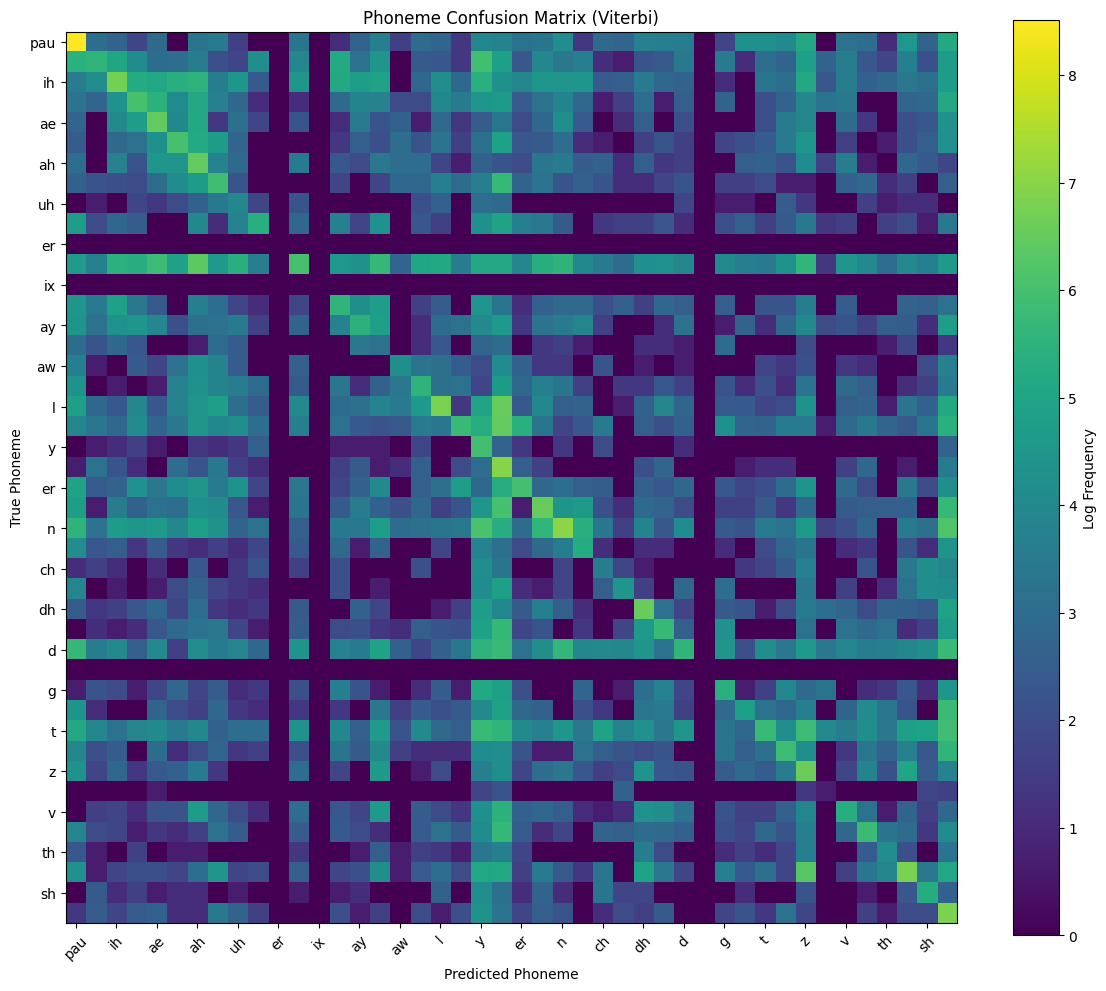


--- Per-Phoneme Metrics ---
 pau: Precision = 0.67, Recall = 0.79
  iy: Precision = 0.35, Recall = 0.11
  ih: Precision = 0.42, Recall = 0.23
  eh: Precision = 0.27, Recall = 0.22
  ae: Precision = 0.32, Recall = 0.42
  aa: Precision = 0.28, Recall = 0.31
  ah: Precision = 0.20, Recall = 0.47
  ao: Precision = 0.23, Recall = 0.31
  uh: Precision = 0.06, Recall = 0.25
  uw: Precision = 0.41, Recall = 0.21
  ax: Precision = 0.37, Recall = 0.08
  ey: Precision = 0.22, Recall = 0.22
  ay: Precision = 0.26, Recall = 0.17
  oy: Precision = 0.01, Recall = 0.10
  aw: Precision = 0.23, Recall = 0.14
  ow: Precision = 0.29, Recall = 0.26
   l: Precision = 0.55, Recall = 0.30
   r: Precision = 0.43, Recall = 0.12
   y: Precision = 0.09, Recall = 0.83
   w: Precision = 0.15, Recall = 0.81
  er: Precision = 0.37, Recall = 0.23
   m: Precision = 0.36, Recall = 0.31
   n: Precision = 0.46, Recall = 0.26
  ng: Precision = 0.19, Recall = 0.30
  ch: Precision = 0.07, Recall = 0.09
  jh: Precision = 0.2

In [33]:
import matplotlib.pyplot as plt

# Plotting the Confusion Matrix
plt.figure(figsize=(12, 10))
plt.imshow(np.log(conf_mat + 1), cmap='viridis') # Log scale helps highlight smaller confusions
plt.colorbar(label='Log Frequency')
plt.title('Phoneme Confusion Matrix (Viterbi)')
plt.xlabel('Predicted Phoneme')
plt.ylabel('True Phoneme')

# Add ticks for the most common phonemes to keep the axis readable
step = 2
plt.xticks(np.arange(0, K, step), [PHONEMES[i] for i in range(0, K, step)], rotation=45)
plt.yticks(np.arange(0, K, step), [PHONEMES[i] for i in range(0, K, step)])

plt.tight_layout()
plt.show()

# Print Precision and Recall metrics for the report
print("\n--- Per-Phoneme Metrics ---")
for i in range(K):
    # Only print metrics for phonemes that actually appeared in the test set
    if np.sum(conf_mat[i, :]) > 0:
        print(f"{PHONEMES[i]:>4}: Precision = {precision[i]:.2f}, Recall = {recall[i]:.2f}")